# Depression Risk Prediction, EDA & Model Training
This notebook performs exploratory data analysis, trains a classification model, and saves it for deployment.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,roc_auc_score, roc_curve, accuracy_score
)
import joblib
import json

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

In [17]:
df = pd.read_csv('Student_Depression.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (27901, 18)
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


## 2. Basic Info & Missing Values

In [18]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing/len(df)*100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct %': missing_pct})
print(missing_df[missing_df['Missing'] > 0])
print('\n=== Describe ===')
df.describe(include='all')

=== Data Types ===
id                                         int64
Gender                                    object
Age                                      float64
City                                      object
Profession                                object
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                            object
Dietary Habits                            object
Degree                                    object
Have you ever had suicidal thoughts ?     object
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness          object
Depression                                 int64
dtype: object

=== Missing Values ===
                  Missing  Pct %
Financial Stress        3   

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,27901.000000,27901,27901.000000,27901,27901,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901,27901,27901,27901,27901.000000,27898.000000,27901,27901.000000
unique,NaN,2,NaN,52,14,NaN,NaN,NaN,NaN,NaN,5,4,28,2,NaN,NaN,2,NaN
top,NaN,Male,NaN,Kalyan,Student,NaN,NaN,NaN,NaN,NaN,Less than 5 hours,Unhealthy,Class 12,Yes,NaN,NaN,No,NaN
freq,NaN,15547,NaN,1570,27870,NaN,NaN,NaN,NaN,NaN,8310,10317,6080,17656,NaN,NaN,14398,NaN
mean,70442.149421,NaN,25.822300,NaN,NaN,3.141214,0.000430,7.656104,2.943837,0.000681,NaN,NaN,NaN,NaN,7.156984,3.139867,NaN,0.585499
std,40641.175216,NaN,4.905687,NaN,NaN,1.381465,0.043992,1.470707,1.361148,0.044394,NaN,NaN,NaN,NaN,3.707642,1.437347,NaN,0.492645
min,2.000000,NaN,18.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,NaN,0.000000
25%,35039.000000,NaN,21.000000,NaN,NaN,2.000000,0.000000,6.290000,2.000000,0.000000,NaN,NaN,NaN,NaN,4.000000,2.000000,NaN,0.000000
50%,70684.000000,NaN,25.000000,NaN,NaN,3.000000,0.000000,7.770000,3.000000,0.000000,NaN,NaN,NaN,NaN,8.000000,3.000000,NaN,1.000000
75%,105818.000000,NaN,30.000000,NaN,NaN,4.000000,0.000000,8.920000,4.000000,0.000000,NaN,NaN,NaN,NaN,10.000000,4.000000,NaN,1.000000


## 3. Target Distribution

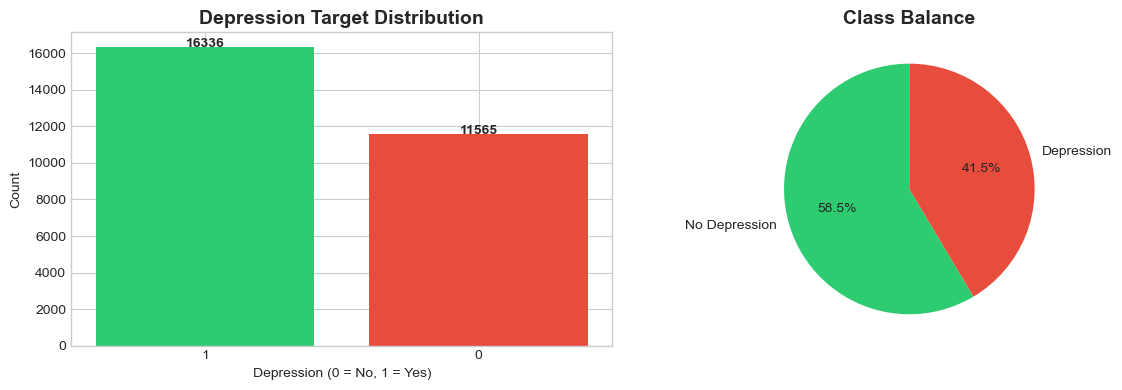

Class balance: {1: 16336, 0: 11565}


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
val_counts = df['Depression'].value_counts()
axes[0].bar(val_counts.index.astype(str), val_counts.values, color=['#2ecc71','#e74c3c'])
axes[0].set_title('Depression Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Depression (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')
for i, v in enumerate(val_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(val_counts.values, labels=['No Depression','Depression'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class balance: {val_counts.to_dict()}')

## 4. Numerical Feature EDA

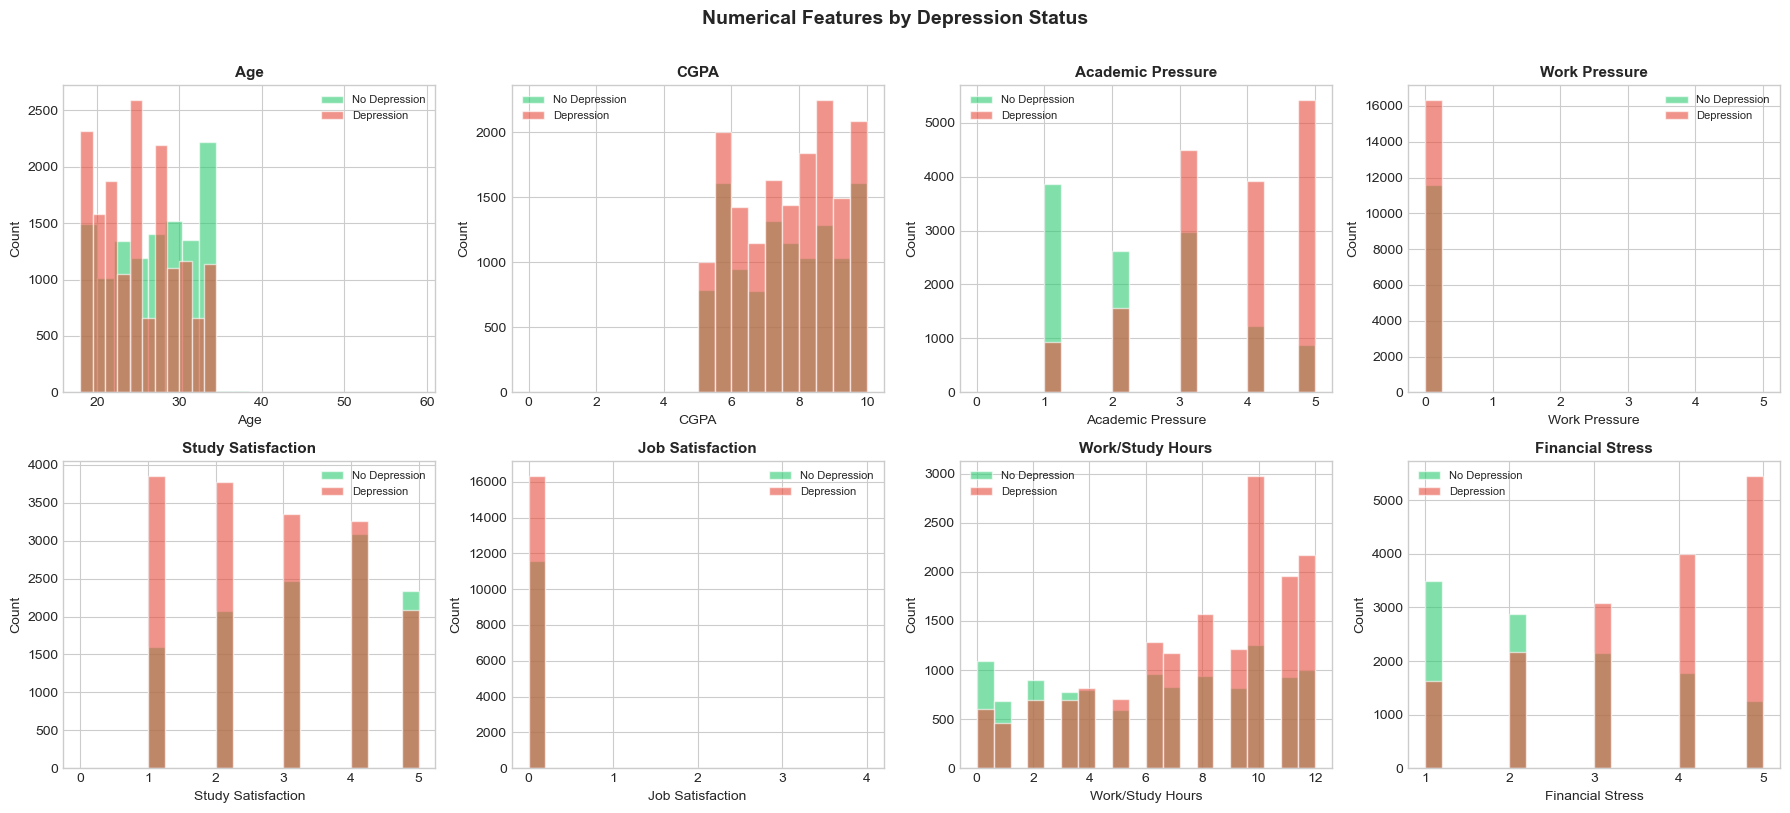

In [20]:
num_cols = ['Age', 'CGPA', 'Academic Pressure', 'Work Pressure','Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        for dep_val, color, label in [(0,'#2ecc71','No Depression'),(1,'#e74c3c','Depression')]:
            subset = df[df['Depression'] == dep_val][col].dropna()
            axes[i].hist(subset, alpha=0.6, color=color, label=label, bins=20, edgecolor='white')
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].legend(fontsize=8)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features by Depression Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Categorical Feature EDA

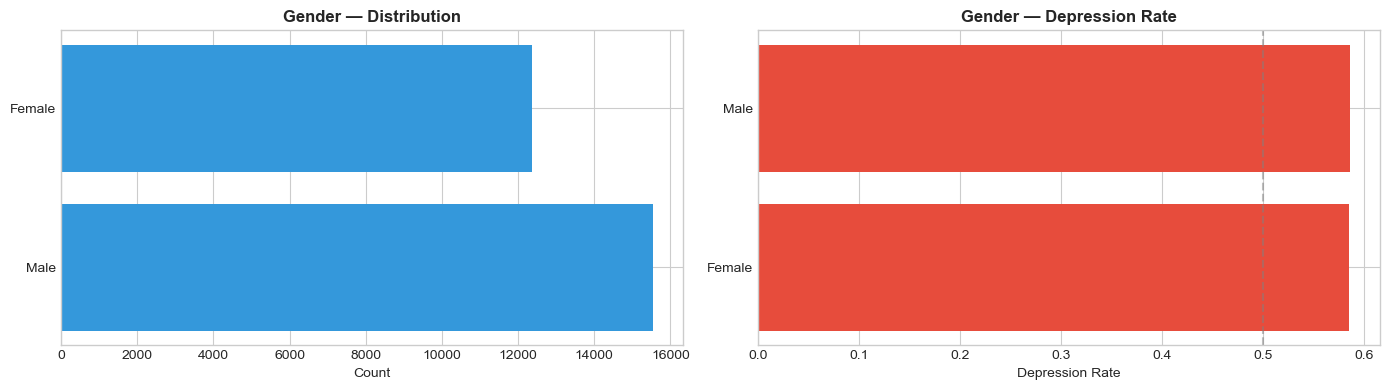

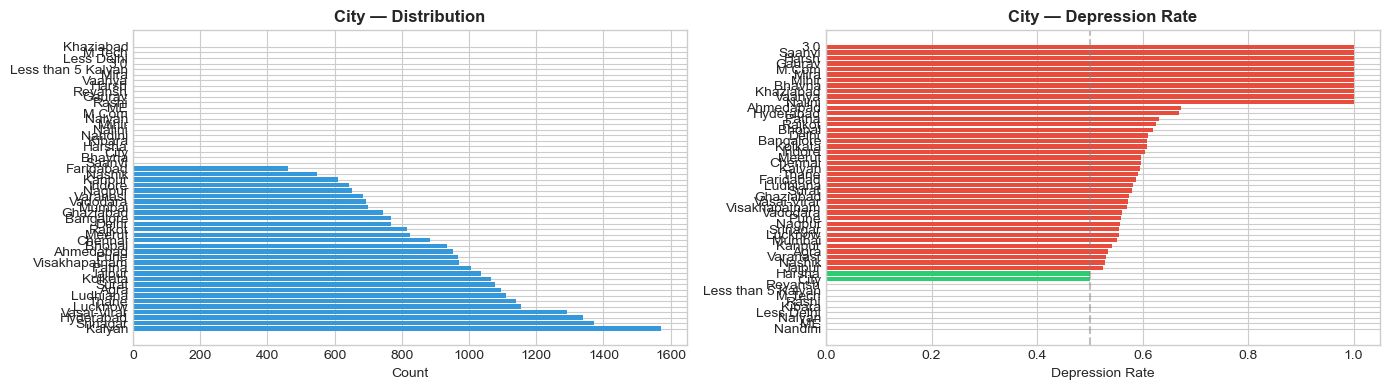

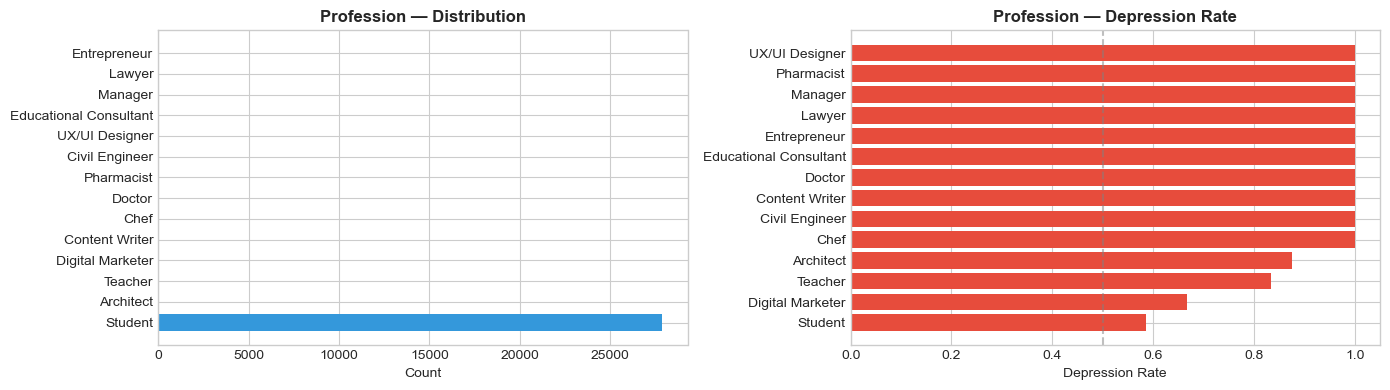

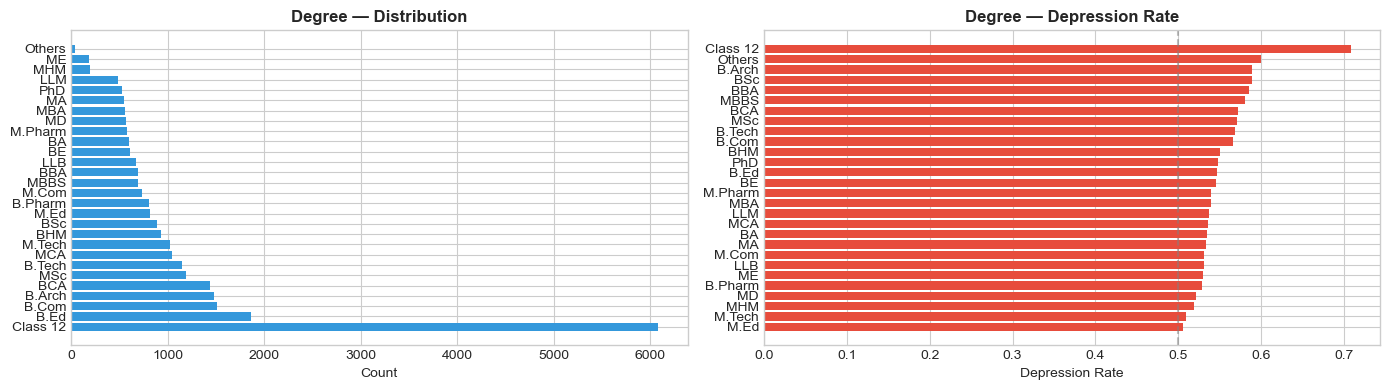

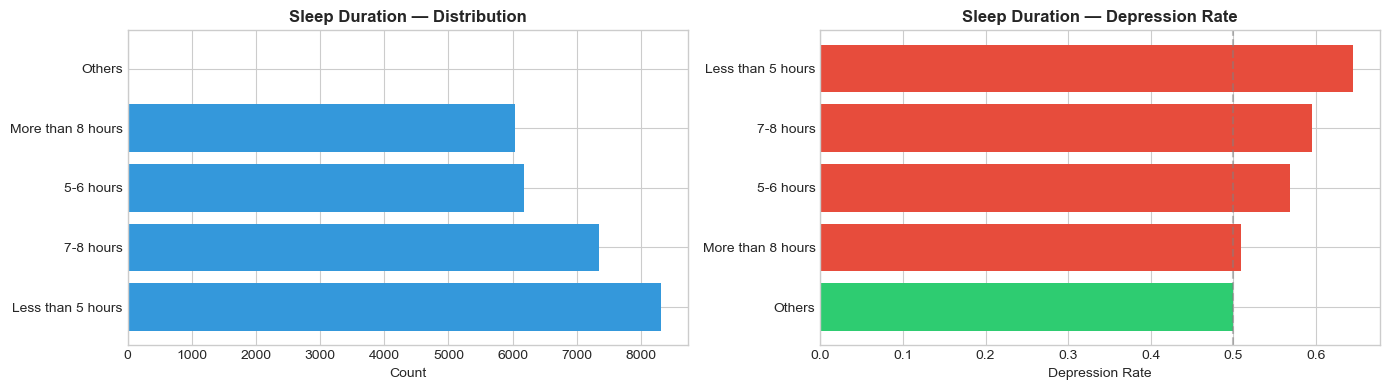

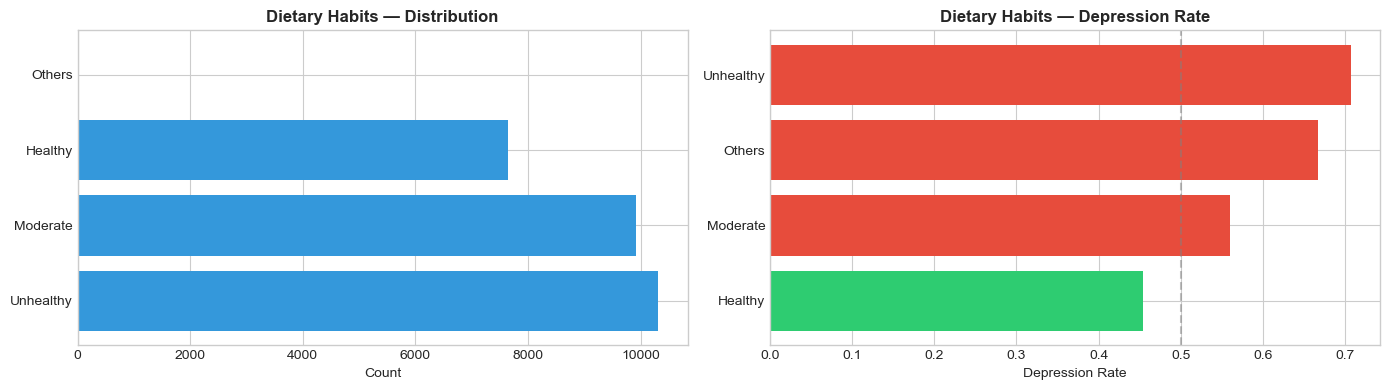

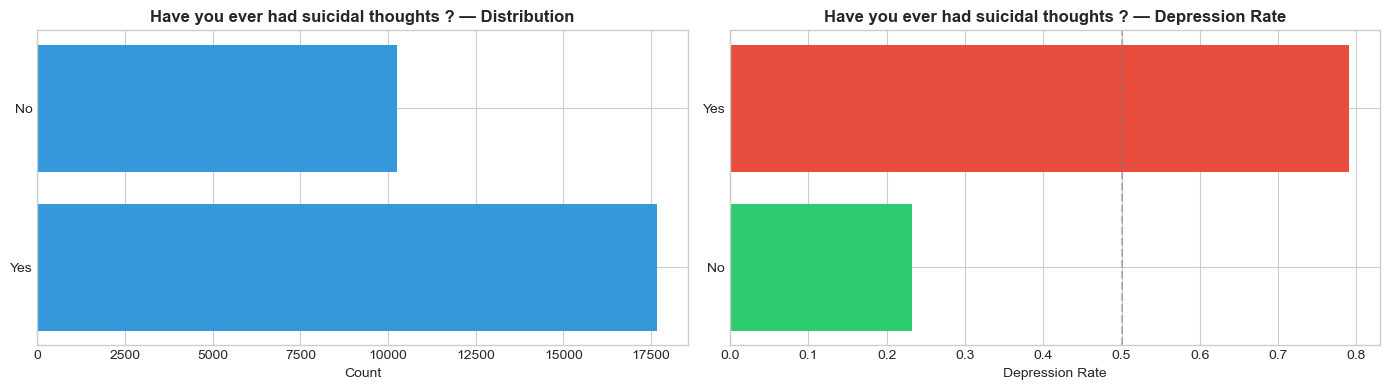

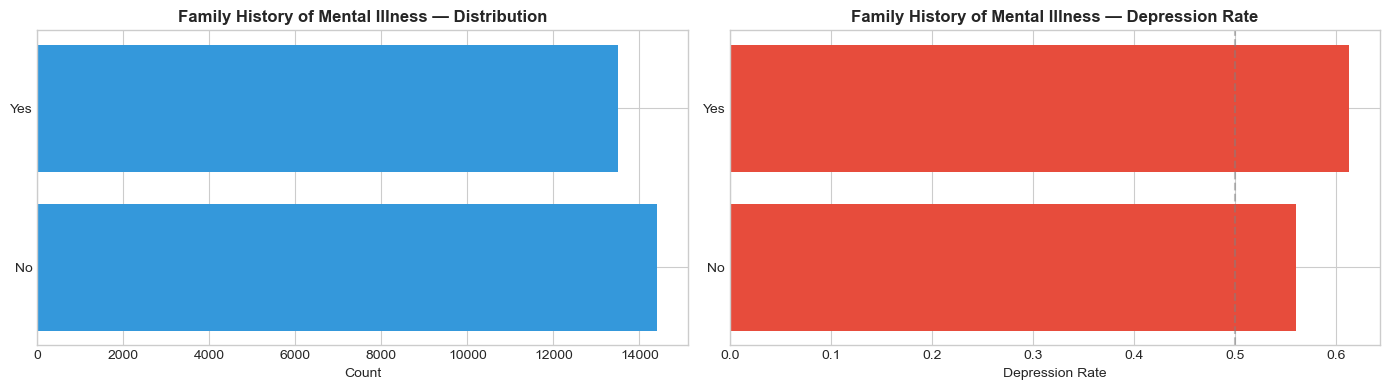

In [21]:
cat_cols = ['Gender', 'City', 'Profession', 'Degree', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']
cat_cols = [c for c in cat_cols if c in df.columns]

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Value counts
    vc = df[col].value_counts()
    axes[0].barh(vc.index.astype(str), vc.values, color='#3498db')
    axes[0].set_title(f'{col} — Distribution', fontweight='bold')
    axes[0].set_xlabel('Count')
    
    # Depression rate per category
    dep_rate = df.groupby(col)['Depression'].mean().sort_values(ascending=True)
    colors = ['#e74c3c' if v > 0.5 else '#2ecc71' for v in dep_rate.values]
    axes[1].barh(dep_rate.index.astype(str), dep_rate.values, color=colors)
    axes[1].set_title(f'{col} — Depression Rate', fontweight='bold')
    axes[1].set_xlabel('Depression Rate')
    axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## 6. Correlation Heatmap

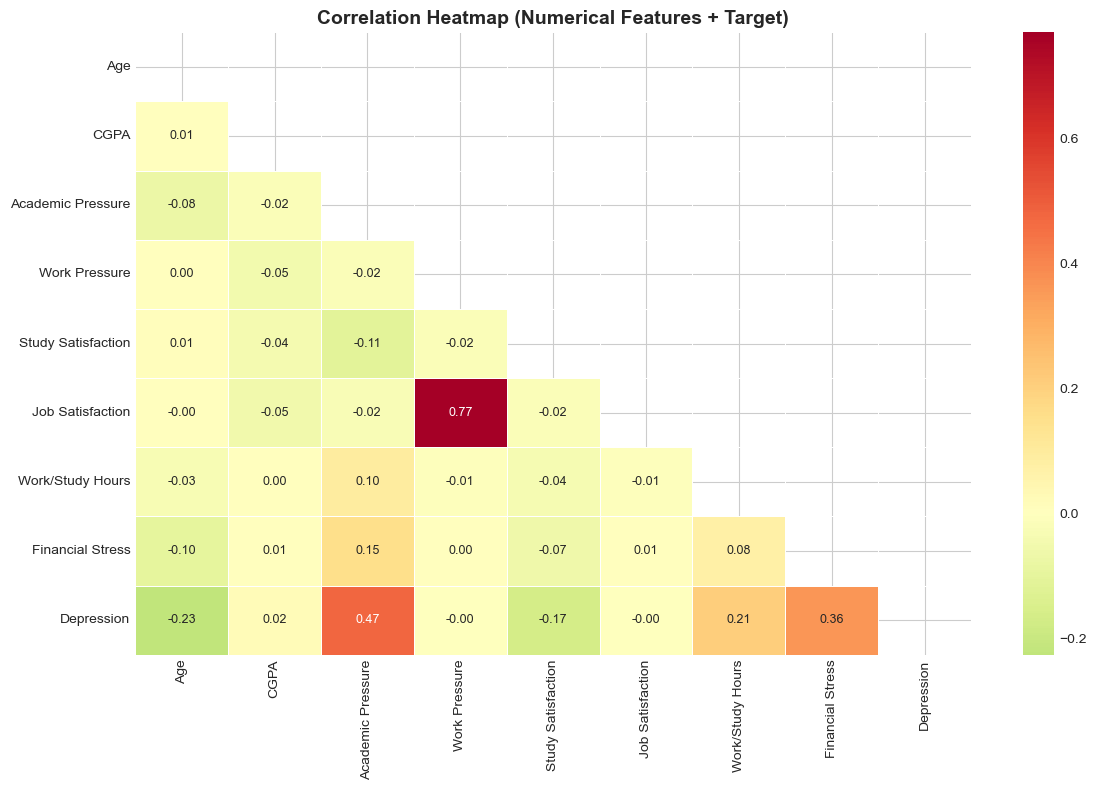

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[num_cols + ['Depression']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap (Numerical Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Preprocessing

In [23]:
df_model = df.copy()
if 'id' in df_model.columns:
    df_model.drop(columns=['id'], inplace=True)

for col in df_model.select_dtypes(include='number').columns:
    df_model[col].fillna(df_model[col].median(), inplace=True)
for col in df_model.select_dtypes(include='object').columns:
    df_model[col].fillna(df_model[col].mode()[0], inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = {cls: int(idx) for idx, cls in enumerate(le.classes_)}

with open('label_encodings.json', 'w') as f:
    json.dump(le_dict, f, indent=2)

print('Preprocessing done. Shape:', df_model.shape)
df_model.head()

Preprocessing done. Shape: (27901, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,51,11,5.0,0.0,8.97,2.0,0.0,0,0,3,1,3.0,1.0,0,1
1,0,24.0,3,11,2.0,0.0,5.90,5.0,0.0,0,1,10,0,3.0,2.0,1,0
2,1,31.0,44,11,3.0,0.0,7.03,5.0,0.0,2,0,5,0,9.0,1.0,1,0
3,0,28.0,49,11,3.0,0.0,5.59,2.0,0.0,1,1,7,1,4.0,5.0,1,1
4,0,25.0,16,11,4.0,0.0,8.13,3.0,0.0,0,1,17,1,1.0,1.0,0,0


## 8. Train/Test Split

In [24]:
X = df_model.drop(columns=['Depression'])
y = df_model['Depression']
feature_cols = list(X.columns)
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')

Train: (22320, 16), Test: (5581, 16)
Train positive rate: 0.585
Test  positive rate: 0.586


## 9. Model Training — Gradient Boosting

In [25]:
model = GradientBoostingClassifier(n_estimators=300,learning_rate=0.05,max_depth=4,subsample=0.8,random_state=42)
model.fit(X_train, y_train)

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print(f'CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Depression','Depression']))

CV AUC: 0.9202 ± 0.0050
Test Accuracy : 0.8441
Test ROC-AUC  : 0.9190

Classification Report:
               precision    recall  f1-score   support

No Depression       0.82      0.79      0.81      2313
   Depression       0.86      0.88      0.87      3268

     accuracy                           0.84      5581
    macro avg       0.84      0.84      0.84      5581
 weighted avg       0.84      0.84      0.84      5581



## 10. Save Model

In [27]:
joblib.dump(model, 'depression_model.pkl')
print('Model saved → depression_model.pkl')
print('Encodings saved → label_encodings.json')
print('Feature list saved → feature_columns.json')
print(f'\nModel summary: {model.__class__.__name__}')
print(f'  n_estimators : {model.n_estimators}')
print(f'  learning_rate: {model.learning_rate}')
print(f'  max_depth    : {model.max_depth}')
print(f'  Test AUC     : {roc_auc_score(y_test, y_prob):.4f}')
print(f'  Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Model saved → depression_model.pkl
Encodings saved → label_encodings.json
Feature list saved → feature_columns.json

Model summary: GradientBoostingClassifier
  n_estimators : 300
  learning_rate: 0.05
  max_depth    : 4
  Test AUC     : 0.9190
  Test Accuracy: 0.8441


In [28]:
print(type(joblib.load("depression_model.pkl")))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
